In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
                             mean_absolute_error,
                             mean_absolute_percentage_error,
                             r2_score,
                             root_mean_squared_error,
)
from sklearn.model_selection import GridSearchCV, train_test_split

sns.set()

# Support Vector Machines

## SVM como regresión
**Aprendizaje de Máquina - CEIA - FIUBA**

Como vimos en clase, SVM tambien se puede usar para realizar regresiones. Scikit-learn nos ofrece la clase [SVR](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html#sklearn.svm.SVR) que es la implementación de SVM para regresión. 

Para practicar este modelo, vamos a usar el dataset **Hitters**, el cual contiene datos de jugadores de beisbol de la liga estadounidense de 1986 y 1987. Contiene 322 observaciones con 20 datos. Este conjunto de datos se tomó de la biblioteca StatLib que se mantiene en la Universidad Carnegie Mellon. Los datos salariales fueron originalmente de Sports Illustrated, 20 de abril de 1987. Las estadísticas de 1986 y de carrera se obtuvieron de The 1987 Baseball Encyclopedia Update publicado por Collier Books, Macmillan Publishing Company, Nueva York. Que significa cada cosa está [explicado aquí](https://rdrr.io/cran/ISLR/man/Hitters.html).

Lo que queremos hacer es tener alguna regresión de los salarios de 1987 los jugadores usando como base los datos de ellos de su perfomance en 1986.

> El análisis exploratorio completo del dataset (distribución del target, justificación de la transformación logarítmica, correlaciones, multicolinealidad y el baseline) está en la notebook auxiliar [`EDA - Hitters.ipynb`](EDA%20-%20Hitters.ipynb). Acá nos quedamos con el preprocesamiento y el modelado.

In [2]:
# Cargamos el dataset
df_hitters = pd.read_csv("datasets/Hitters.csv")

In [3]:
df_hitters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

In [4]:
# Como los datos de salario no están completos, descartamos a aquellos jugadores que 
# no tienen ese dato.
df_hitters.dropna(subset="Salary", inplace=True)

In [5]:
# Modelamos el logaritmo del salario: en el EDA vimos que reduce la fuerte
# asimetría del target y mejora la dispersión de los salarios bajos.
df_hitters["Salary_log"] = np.log(df_hitters["Salary"])

Todas las variables son numéricas salvo *League*, *Division* y *NewLeague*, que convertimos en variables dummy:

In [6]:
df_hitters_dummies = pd.get_dummies(data=df_hitters, 
                                    columns=['League', 'Division', 'NewLeague'],
                                    drop_first=True)

In [7]:
df_hitters_dummies.columns

Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists',
       'Errors', 'Salary', 'Salary_log', 'League_N', 'Division_W',
       'NewLeague_N'],
      dtype='object')

Obtenemos los arrays.

In [8]:
X_cols = ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 
          'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', 
          'League_N', 'Division_W', 'NewLeague_N']

X = df_hitters_dummies.loc[:, X_cols]
# Y como variable a predecir a Salary
y = df_hitters_dummies.loc[:, 'Salary_log']

Separamos en el dataset de entrenamiento y testeo.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
    random_state=42)

Ahora escalamos las variables.

In [10]:
from sklearn.preprocessing import StandardScaler

sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train)
X_test = sc_x.transform(X_test)

## Regresión con SVR

Hacemos una búsqueda de hiper-parámetros:

In [11]:
from sklearn.svm import SVR

svm_hitters = SVR()

grid = GridSearchCV(svm_hitters,
                    [{"C": [0.01, 0.1, 1, 5, 10, 100], "kernel": ["linear"]},
                     {"C": [0.01, 0.1, 1, 5, 10, 100], 
                      "gamma": [0.1, 0.5, 1, 2, 10, 100], "kernel": ["rbf", "sigmoid"]},
                     {"C": [0.01, 0.1, 1, 5, 10, 100], "degree": [2, 3, 4, 5, 6], 
                      "kernel": ["poly"]}],
                    refit=True,
                    cv=5,
                    scoring='neg_mean_absolute_error')
grid.fit(X_train,y_train)

,estimator,SVR()
,param_grid,"[{'C': [0.01, 0.1, ...], 'kernel': ['linear']}, {'C': [0.01, 0.1, ...], 'gamma': [0.1, 0.5, ...], 'kernel': ['rbf', 'sigmoid']}, ...]"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'rbf'


In [12]:
grid.best_params_

{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}

Según esta busqueda el mejor modelo es uno con función radial.

Evaluemos este modelo con el set de testeo.

In [13]:
y_pred = grid.predict(X_test)

# equivalente:
# svm_hitters_best = grid.best_estimator_
# y_pred = svm_hitters_best.predict(X_test)

In [14]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE de testeo fue: {mae}")
print(f"RMSE de testeo fue: {rmse}")
print(f"MAPE de testeo fue: {mape}")
print(f"R2 de testeo fue: {r2}")

MAE de testeo fue: 0.3917577246002783
RMSE de testeo fue: 0.5702031555139366
MAPE de testeo fue: 0.06831807029280854
R2 de testeo fue: 0.5828398458336208


El SVR obtuvo un **MAE de testeo de 0.39**. Veamos cómo se compara contra el baseline y los modelos lineales que desarrollamos en las notebooks auxiliares.

---
## Comparativa final

Reunimos todos los modelos de regresión entrenados sobre Hitters con el mismo split (`test_size=0.3`, `random_state=42`), para compararlos sobre el mismo conjunto de testeo:

- **Baseline (tramos de años)** — tabla de referencia que predice el salario promedio según el tramo de experiencia del jugador (definido en la notebook auxiliar [`EDA - Hitters.ipynb`](EDA%20-%20Hitters.ipynb)).
- **Regresión Lineal (OLS)** y **Ridge** — modelos lineales desarrollados en la notebook auxiliar [`Auxiliar - Regresion Lineal.ipynb`](Auxiliar%20-%20Regresion%20Lineal.ipynb) (ahí también está Lasso y el análisis de multicolinealidad).
- **SVR (RBF)** — el mejor SVR encontrado, el único modelo que desarrollamos en este notebook.

La métrica es el **MAE** (menor es mejor).

In [15]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline

# X sigue siendo el DataFrame sin escalar; rehacemos el split (mismos parámetros
# -> mismo conjunto de test) para el baseline y los modelos lineales.
X_raw_train, X_raw_test, _, _ = train_test_split(X, y, test_size=0.3,
    random_state=42)

# Baseline: promedio de log(Salary) por tramo de años (ver EDA - Hitters).
# Los promedios se calculan sólo sobre train.
bins = [0, 2, 4, 6, 9, 13, np.inf]
tramo_train = pd.cut(X_raw_train["Years"], bins=bins)
tramo_test = pd.cut(X_raw_test["Years"], bins=bins)
prom_por_tramo = y_train.groupby(tramo_train, observed=False).mean()
y_pred_base = tramo_test.map(prom_por_tramo).astype(float).values

# Modelos lineales (mejor alpha de Ridge hallado en Auxiliar - Regresion Lineal)
ols = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
ols.fit(X_raw_train, y_train)
y_pred_ols = ols.predict(X_raw_test)

ridge = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=13.67))])
ridge.fit(X_raw_train, y_train)
y_pred_ridge = ridge.predict(X_raw_test)

# SVR: y_pred ya fue calculado más arriba
modelos = ["Baseline (tramos de años)", "Regresión Lineal", "Ridge", "SVR (RBF)"]
preds = [y_pred_base, y_pred_ols, y_pred_ridge, y_pred]

df_cmp = pd.DataFrame({
    "MAE": [mean_absolute_error(y_test, p) for p in preds],
    "RMSE": [root_mean_squared_error(y_test, p) for p in preds],
    "R2": [r2_score(y_test, p) for p in preds],
}, index=pd.Index(modelos))

df_cmp.round(4)

,MAE,RMSE,R2
Baseline (tramos de años),0.5068,0.7027,0.3665
Regresión Lineal,0.5154,0.6779,0.4103
Ridge,0.5118,0.6626,0.4366
SVR (RBF),0.3918,0.5702,0.5828


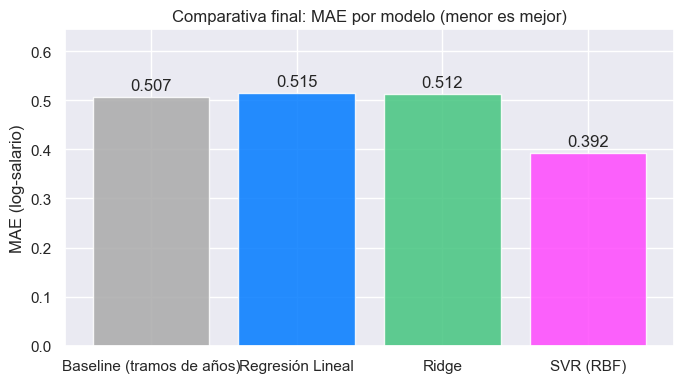

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
colores = ["#aaaaaa", "#007aff", "#44c57f", "#ff48fd"]
bars = ax.bar(df_cmp.index, df_cmp["MAE"], color=colores, alpha=0.85)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_ylabel("MAE (log-salario)")
ax.set_title("Comparativa final: MAE por modelo (menor es mejor)")
ax.set_ylim(0, df_cmp["MAE"].max() * 1.25)
plt.tight_layout()
plt.show()

### Observaciones

- El **SVR (RBF)** es claramente el mejor modelo: **MAE ≈ 0.39** y el mayor R² (≈ 0.58), muy por debajo del resto. El kernel no lineal captura relaciones que los modelos lineales no pueden.
- El **baseline por tramos de años** es sorprendentemente fuerte: en **MAE (≈ 0.51)** llega a igualar —e incluso rozar por debajo— a la regresión lineal y a Ridge, ¡sólo mirando la experiencia del jugador! En **RMSE y R²**, en cambio, los modelos lineales lo superan (penalizan más los errores grandes que el baseline comete con los outliers).
- Que los modelos lineales apenas mejoren sobre el baseline confirma lo que veíamos en el EDA: buena parte de la señal "fácil" del salario está en los años de carrera, y la multicolinealidad limita lo que un modelo lineal puede aportar por encima de eso.